# Initial Data Exploration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json
import math
from pathlib import Path

## Load in the Data

In [37]:
train = pd.read_csv('data/train.csv') # user item interaction data
test_pairs = pd.read_csv('data/test_pairs.csv') # user item pairs we need to predict ratings off
movies = pd.read_csv('data/movies.csv') # movie metadata, we are given that tehre are 18 genres
users = pd.read_csv('data/users.csv') # user metadata 

In [ ]:
with open("data/split_stats.json") as f:
    split_stats = json.load(f)

Lets get some basic stats of the data

In [7]:
train.head(10)

,user_id,item_id,rating,timestamp
0,1,3186,4,978300019
1,1,1721,4,978300055
2,1,1270,5,978300055
3,1,1022,5,978300055
4,1,2340,3,978300103
5,1,1836,5,978300172
6,1,3408,4,978300275
7,1,2804,5,978300719
8,1,1207,4,978300719
9,1,260,4,978300760


test_pairs.csv is the csv that holds a ruser id and item id pair and our goal is to predict the rating the user gave that specific item (movie).  
Things to consider *Cold-start items in test (never in train)* these are items that have no interaction history. All users appear in train and test.

In [8]:
len(train)

797758

In [10]:
print(f" # of Test pairs: {len(test_pairs)}")
print(f" # of Unique users in train: {train['user_id'].nunique()}")
print(f" # of Unique items in train:  {train['item_id'].nunique()}")
print(f" # of Items in movies.csv: {len(movies)}")
print(f" # of Users in users.csv: {len(users)}")

 # of Test pairs: 202451
 # of Unique users in train: 6040
 # of Unique items in train:  3666
 # of Items in movies.csv: 3883
 # of Users in users.csv: 6040


In [16]:
train['rating'].describe()

count    797758.000000
mean          3.616840
std           1.110276
min           1.000000
25%           3.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

Lets do a quick check on NA values

In [17]:
train.isna().sum()

user_id      0
item_id      0
rating       0
timestamp    0
dtype: int64

In [18]:
movies.isna().sum()

item_id    0
title      0
year       0
genres     0
dtype: int64

In [19]:
users.isna().sum()

user_id       0
gender        0
age_group     0
occupation    0
dtype: int64

## Plot Rating Distributions 

We will look at the distribution of the training data. 

In [21]:
ating_count = train["rating"].value_counts().sort_index()

(array([ 42207.,      0.,  81748.,      0.,      0., 204611.,      0.,
        280133.,      0., 189059.]),
 array([1. , 1.4, 1.8, 2.2, 2.6, 3. , 3.4, 3.8, 4.2, 4.6, 5. ]),
 <BarContainer object of 10 artists>)

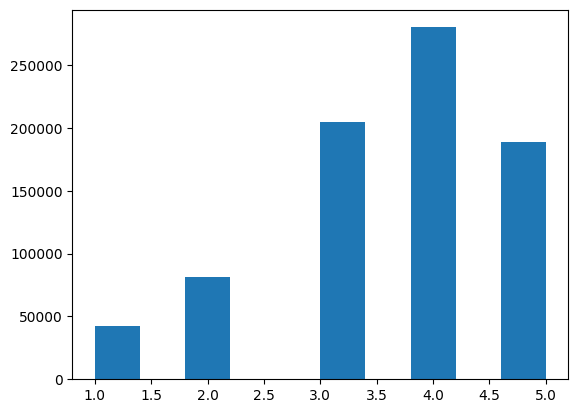

In [25]:
plt.hist(train['rating'])

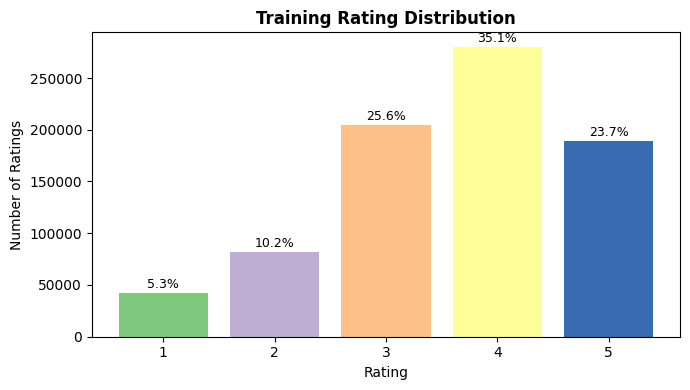

In [31]:
rating_count = train["rating"].value_counts().sort_index()  # getting the counts of each rating
rating_pct = rating_count/rating_count.sum() * 100 # getting what paercent of the ratings each erating teaes up

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(rating_count.index, rating_count.values, color=sns.color_palette("Accent"))

# Annotate each bar with count and percentage
for bar, count, pct in zip(bars, rating_count.values, rating_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2000, f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Rating")
ax.set_ylabel("Number of Ratings")
ax.set_title("Training Rating Distribution",fontweight="bold")
ax.set_xticks([1, 2, 3, 4, 5])
plt.tight_layout()

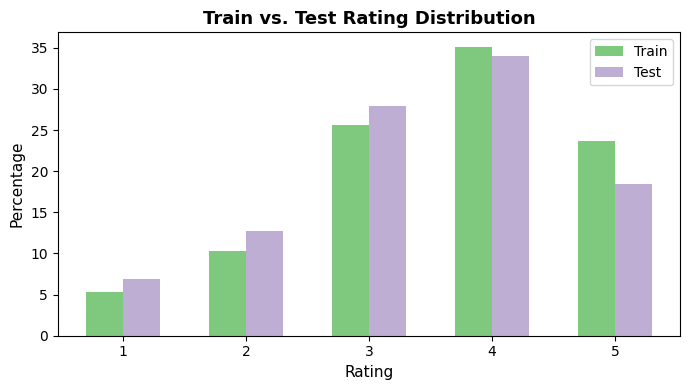

In [36]:
# we know test ratings stats from split_stats.json 
ratings    = [1, 2, 3, 4, 5]
train_percentile = [train_hist[str(r)]/ sum(train_hist.values()) * 100 for r in ratings]
test_percentiles  = [test_hist[str(r)] / sum(test_hist.values())  * 100 for r in ratings]
x = np.arange(len(ratings))
width = 0.3
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width/2, train_percentile, width, label="Train", color=sns.color_palette("Accent")[0])
ax.bar(x + width/2, test_percentiles,  width, label="Test", color=sns.color_palette("Accent")[1])

ax.set_xlabel("Rating", fontsize=11)
ax.set_ylabel("Percentage", fontsize=11)
ax.set_title("Train vs. Test Rating Distribution", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(ratings)
ax.legend()
plt.tight_layout()
plt.show()

In [34]:
print(f"Train mean: {train_mean:.4f}  & Test mean: {test_mean:.4f}")

Train mean: 3.6168  & Test mean: 3.4426


## User Activity Distribution
We want to also see how many reviews each user has, we are looking to see if there is a skewed distribution.

In [ ]:
train.groupby("user_id").size().

user_id
1        42
2       103
3        40
4        16
5       158
       ... 
6036    710
6037    161
6038     16
6039     98
6040    272
Length: 6040, dtype: int64

In [43]:
user_counts = train.groupby("user_id").size()  # number of ratings per user
print(f"median ratings per user:{user_counts.median()}")
print(f"mean ratings per user:{user_counts.mean()}")
print(f"min & max: min is {user_counts.min()} & max is {user_counts.max()}")
print(f"users with less than 20 ratings: {(user_counts < 20).sum():,}")
print(f"users with more than 200 ratings: {(user_counts >= 200).sum():,}")


median ratings per user:76.0
mean ratings per user:132.07913907284768
min & max: min is 16 & max is 1851
users with less than 20 ratings: 416
users with more than 200 ratings: 1,225


/var/folders/sz/_mlq7slj15vg1f70zg680jwr0000gn/T/ipykernel_21096/2214317991.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(fontsize=9)


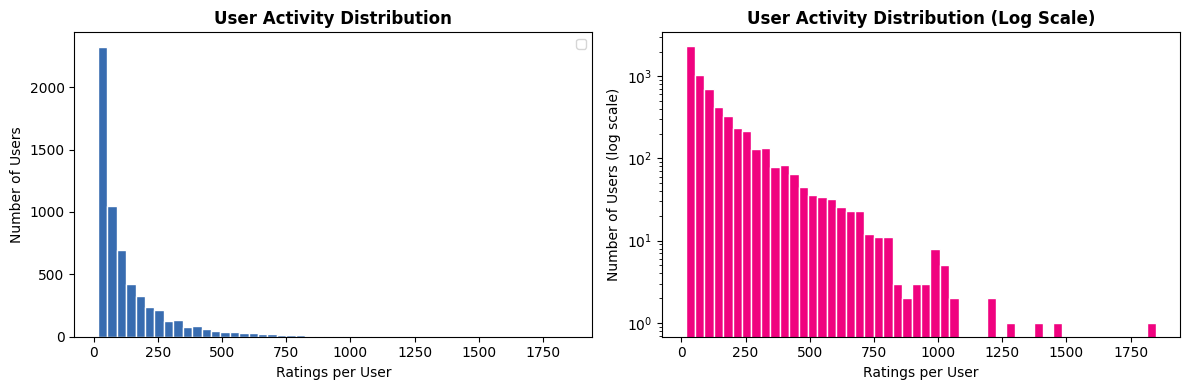

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(user_counts, bins=50, color=sns.color_palette("Accent")[4], edgecolor="white")
axes[0].set_xlabel("Ratings per User")
axes[0].set_ylabel("Number of Users")
axes[0].set_title("User Activity Distribution", fontweight="bold")
axes[0].legend(fontsize=9)


# graph in log scale to make more visual understanding 
axes[1].hist(user_counts, bins=50, color=sns.color_palette("Accent")[5], edgecolor="white", log=True)
axes[1].set_xlabel("Ratings per User")
axes[1].set_ylabel("Number of Users (log scale)")
axes[1].set_title("User Activity Distribution (Log Scale)", fontweight="bold")

plt.tight_layout()
plt.show()

We see a pretty heavy right skew which shows us most users make around 0-250 ratings but as it gets higher less and less users have 500-750 users.

## Item Popularity Distribution
We are now looking at how many ratings each movie has, once again we are looking to see if there is a noticeable skew. 

In [57]:
item_counts = train.groupby("item_id").size()  # number of ratings per item
print(f" median ratings per item: {item_counts.median()}")
print(f" mean ratings per item: {item_counts.mean()}")
print(f" min & max: {item_counts.min()} & {item_counts.max()}")
print(f" items with less than 10 ratings: {(item_counts < 10).sum()}")
print(f" items with over 500 ratings: {(item_counts >= 500).sum():,}")

 median ratings per item: 91.5
 mean ratings per item: 217.60992907801418
 min & max: 1 & 3153
 items with less than 10 ratings: 514
 items with over 500 ratings: 477


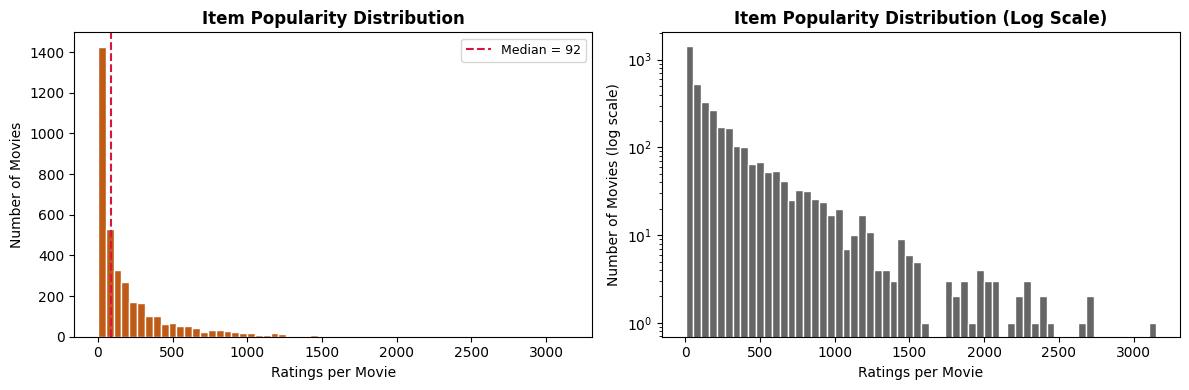

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(item_counts, bins=60, color=sns.color_palette("Accent")[6], edgecolor="white")
axes[0].axvline(item_counts.median(), color="crimson", linestyle="--", label=f"Median = {item_counts.median():.0f}")
axes[0].set_xlabel("Ratings per Movie")
axes[0].set_ylabel("Number of Movies")
axes[0].set_title("Item Popularity Distribution", fontweight="bold")
axes[0].legend(fontsize=9)

axes[1].hist(item_counts, bins=60, color=sns.color_palette("Accent")[7], edgecolor="white", log=True)
axes[1].set_xlabel("Ratings per Movie")
axes[1].set_ylabel("Number of Movies (log scale)")
axes[1].set_title("Item Popularity Distribution (Log Scale)", fontweight="bold")

plt.tight_layout()
plt.show()

In [65]:
top20 = (
    train.groupby("item_id")["rating"]
    .agg(["count", "mean"])
    .rename(columns={
        "count": "ratings_count", 
        "mean": "avg_rating"
        })
    .merge(movies[["item_id", "title"]], on="item_id")
    .sort_values("ratings_count", ascending=False)
    .head(20)
)

In [66]:
top20

,item_id,ratings_count,avg_rating,title
2622,2858,3153,4.327942,American Beauty
1091,1196,2731,4.297327,Star Wars: Episode V - The Empire Strikes Back
252,260,2700,4.457037,Star Wars: Episode IV - A New Hope
1105,1210,2651,4.022633,Star Wars: Episode VI - Return of the Jedi
1827,2028,2424,4.341584,Saving Private Ryan
464,480,2392,3.764632,Jurassic Park
570,589,2383,4.083508,Terminator 2: Judgment Day
2347,2571,2330,4.332189,"Matrix, The"
1163,1270,2311,3.994375,Back to the Future
1093,1198,2292,4.474258,Raiders of the Lost Ark


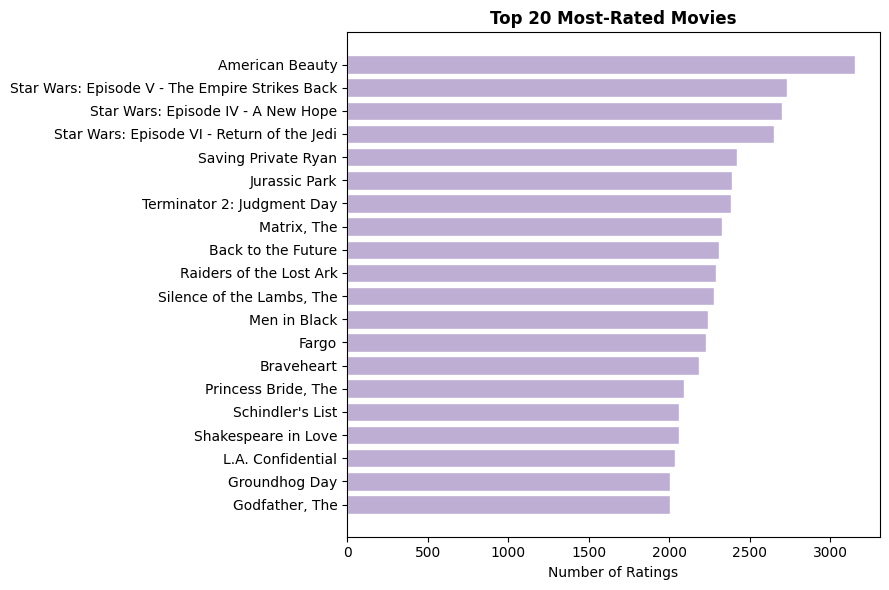

In [77]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top20["title"][::-1], top20["ratings_count"][::-1],
        color=sns.color_palette("Accent")[1], edgecolor="white")
ax.set_xlabel("Number of Ratings")
ax.set_title("Top 20 Most-Rated Movies", fontweight="bold")
plt.tight_layout()
plt.show()

## Genre Analysis
Which genres are most common? Do some genres get systematically higher ratings? Genre signals could help with cold-start items that have no interaction history.

In [79]:
ALL_GENRES = [
    "Action","Adventure","Animation","Children's","Comedy",
    "Crime","Documentary","Drama","Fantasy","Film-Noir",
    "Horror","Musical","Mystery","Romance","Sci-Fi",
    "Thriller","War","Western"
]

In [80]:
for genre in ALL_GENRES:
    movies[genre] = movies["genres"].str.contains(genre, regex=False).astype(float)

genre_movie_counts = movies[ALL_GENRES].sum().sort_values(ascending=False)  # how many movies per genre

In [81]:
genre_movie_counts

Drama          1603.0
Comedy         1200.0
Action          503.0
Thriller        492.0
Romance         471.0
Horror          343.0
Adventure       283.0
Sci-Fi          276.0
Children's      251.0
Crime           211.0
War             143.0
Documentary     127.0
Musical         114.0
Mystery         106.0
Animation       105.0
Western          68.0
Fantasy          68.0
Film-Noir        44.0
dtype: float64

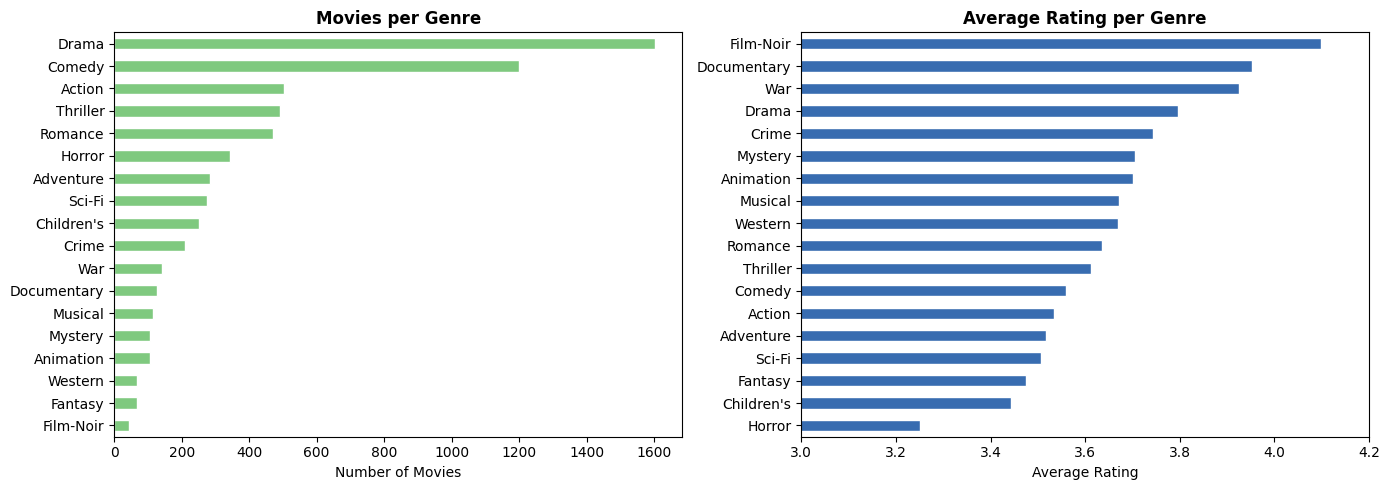

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

genre_movie_counts.plot(kind="barh", ax=axes[0], color=sns.color_palette("Accent")[0], edgecolor="white")
axes[0].set_xlabel("Number of Movies")
axes[0].set_title("Movies per Genre", fontweight="bold")
axes[0].invert_yaxis()

genre_avg.plot(kind="barh", ax=axes[1], color=sns.color_palette("Accent")[4], edgecolor="white")
axes[1].set_xlabel("Average Rating")
axes[1].set_title("Average Rating per Genre", fontweight="bold")
axes[1].set_xlim(3.0, 4.2)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Matrix Sparsity
Only a tiny fraction of the user-movie matrix is filled in. High sparsity is the core challenge for collaborative filtering — models must generalize from the thin slice of observed ratings.

In [85]:
n_users= train["user_id"].nunique()
n_items = train["item_id"].nunique()
n_possible_pairs= n_users * n_items
n_observed_pairs = len(train)
density = n_observed_pairs / n_possible_pairs

print(f" users: {n_users:,}")
print(f" items: {n_items:,}")
print(f" possible pairs:{n_possible_pairs:,}")
print(f" observed ratings:{n_observed_pairs:,}")
print(f" density: {density:.4%}")
print(f" sparsity:{1 - density:.4%}")
print(f"\n only {density:.2%} of the matrix is filled, approximately 1 in every ~{round(1/density)} cells")

 users: 6,040
 items: 3,666
 possible pairs:22,142,640
 observed ratings:797,758
 density: 3.6028%
 sparsity:96.3972%

 only 3.60% of the matrix is filled, approximately 1 in every ~28 cells


## Cold-Start Analysis
Some movies in `test_pairs.csv` never appear in `train.csv` — we have no rating history for them at all. Any model that relies on learned item parameters will have nothing to use for these.

In [ ]:
train_items = set(train["item_id"].unique())
test_items  = set(test_pairs["item_id"].unique())
cold_items  = test_items - train_items

cold_test_pairs = test_pairs[test_pairs["item_id"].isin(cold_items)]
print(f" cold-start items (in test, not in train): {len(cold_items)}")
print(f" test pairs involving cold-start items:    {len(cold_test_pairs):,} ({len(cold_test_pairs)/len(test_pairs)*100:.2f}%)")

cold_movies = movies[movies["item_id"].isin(cold_items)]
print(cold_movies[["item_id", "title", "year", "genres"]].to_string(index=False))

 cold-start items (in test, not in train): 40
 test pairs involving cold-start items:    56 (0.03%)
 item_id                                              title  year                    genres
     134                                      Sonic Outlaws  1995               Documentary
     396                                          Fall Time  1995                     Drama
     572                                    Foreign Student  1994                     Drama
     576                                             Fausto  1993                    Comedy
     584 I Don't Want to Talk About It (De eso no se habla)  1993                     Drama
     658                                    Billy's Holiday  1995                     Drama
     679                            Run of the Country, The  1995                     Drama
     701                                              Daens  1992                     Drama
     706                                        Sunset Park  1996       

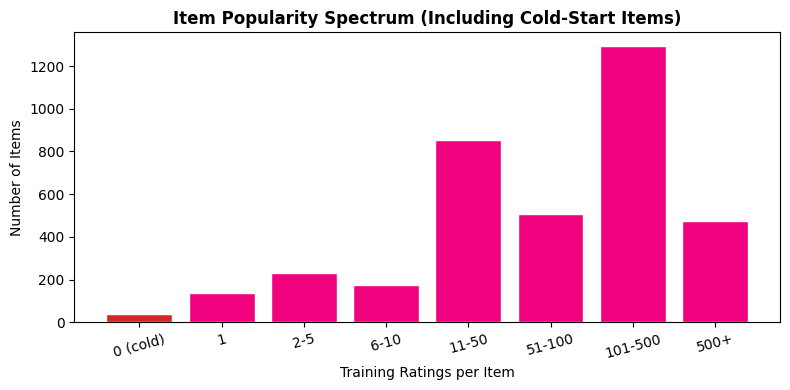

In [74]:
# item popularity spectrum including cold-start
item_counts_df = train.groupby("item_id").size().reset_index(name="n_ratings")
bins   = [0, 1, 5, 10, 50, 100, 500, 10000]
labels = ["1", "2-5", "6-10", "11-50", "51-100", "101-500", "500+"]
item_counts_df["pop_bin"] = pd.cut(item_counts_df["n_ratings"], bins=bins, labels=labels)
pop_summary = item_counts_df.groupby("pop_bin", observed=True).size()

all_bins   = ["0 (cold)"] + list(pop_summary.index.astype(str))
all_counts = [len(cold_items)] + list(pop_summary.values)
bar_colors = ["#d62728"] + [sns.color_palette("Accent")[5]] * len(pop_summary)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(all_bins, all_counts, color=bar_colors, edgecolor="white")
ax.set_xlabel("Training Ratings per Item")
ax.set_ylabel("Number of Items")
ax.set_title("Item Popularity Spectrum (Including Cold-Start Items)", fontweight="bold")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()